<a href="https://colab.research.google.com/github/AbdoGamal74/House-Price-Prediction-using-Linear-Regression/blob/main/HousePricePridector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [325]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Exploring DataSet

In [326]:
data = pd.read_csv('Housing.csv')
df=pd.DataFrame(data)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [327]:
df.columns.to_list()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [328]:
df.shape

(545, 13)

In [329]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [330]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [332]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [333]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning & Feature Engineering

In [334]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})
df.head(20)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,semi-furnished
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,semi-furnished
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,unfurnished
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,furnished
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,unfurnished


In [335]:
df_encoded = pd.get_dummies(df['furnishingstatus'] , prefix= 'furnishing')
df = pd.concat([df.drop(['furnishingstatus'] , axis=1) , df_encoded ] , axis=1)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_furnished,furnishing_semi-furnished,furnishing_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [336]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = df['area'] /( df['bedrooms'] + 1)
df['has_luxury_features'] = df['airconditioning'] + df['hotwaterheating'] + df['basement']
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_furnished,furnishing_semi-furnished,furnishing_unfurnished,total_rooms,area_per_room,has_luxury_features
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False,6,1484.0,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False,8,1792.0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False,5,2490.0,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False,6,1500.0,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False,5,1484.0,2


# visualization

✓ Saved data exploration plot: data_exploration.png


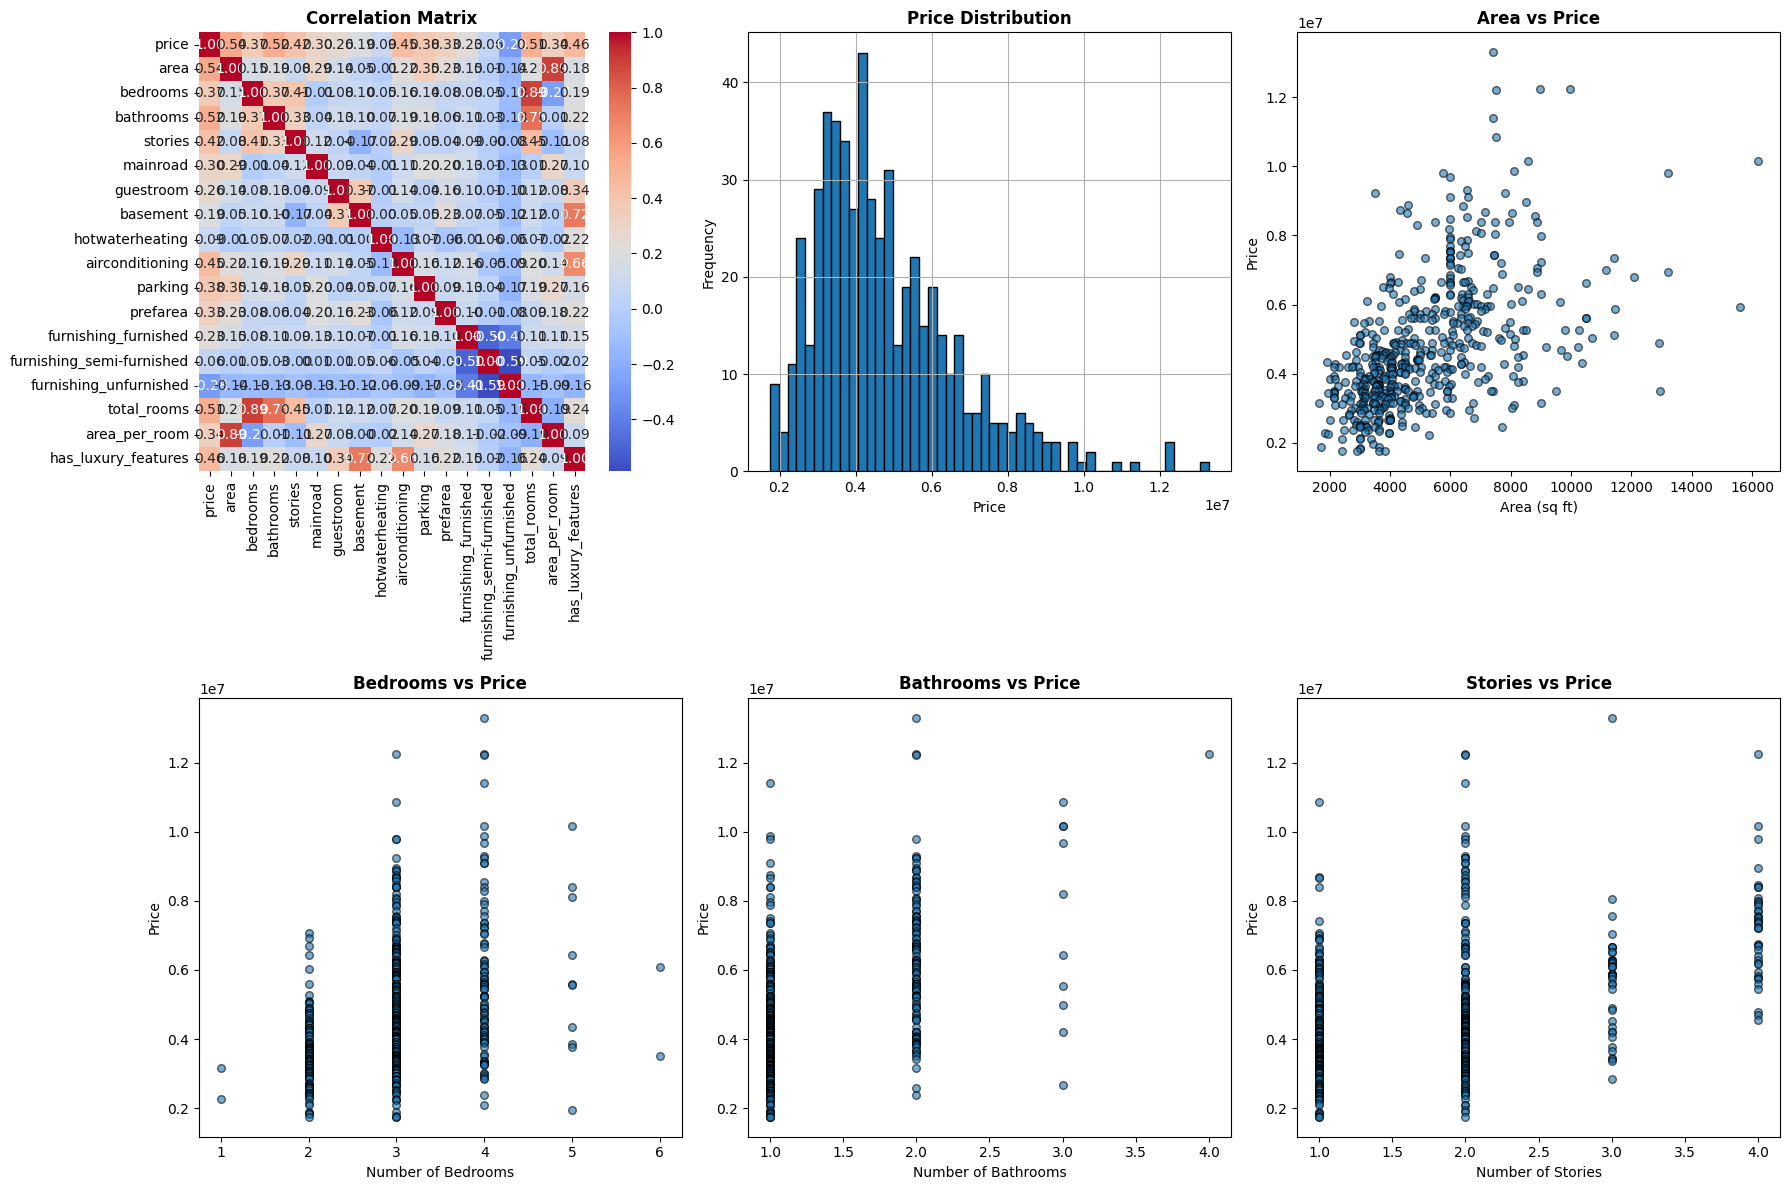

In [337]:
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(2, 3, 1)
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot= True , cmap='coolwarm', fmt='.2f', ax=ax1)
ax1.set_title('Correlation Matrix', fontsize=12, fontweight='bold')

ax2 = plt.subplot(2, 3, 2)
df['price'].hist(bins=50, ax=ax2, edgecolor='black')
ax2.set_title('Price Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price')
ax2.set_ylabel('Frequency')

ax3 = plt.subplot(2, 3, 3)
ax3.scatter(df['area'], df['price'], alpha=0.6, edgecolors='k', s=30)
ax3.set_title('Area vs Price', fontsize=12, fontweight='bold')
ax3.set_xlabel('Area (sq ft)')
ax3.set_ylabel('Price')


ax4 = plt.subplot(2, 3, 4)
ax4.scatter(df['bedrooms'], df['price'], alpha=0.6, edgecolors='k', s=30)
ax4.set_title('Bedrooms vs Price', fontsize=12, fontweight='bold')
ax4.set_xlabel('Number of Bedrooms')
ax4.set_ylabel('Price')

ax5 = plt.subplot(2, 3, 5)
ax5.scatter(df['bathrooms'], df['price'], alpha=0.6, edgecolors='k', s=30)
ax5.set_title('Bathrooms vs Price', fontsize=12, fontweight='bold')
ax5.set_xlabel('Number of Bathrooms')
ax5.set_ylabel('Price')

ax6 = plt.subplot(2, 3, 6)
ax6.scatter(df['stories'], df['price'], alpha=0.6, edgecolors='k', s=30)
ax6.set_title('Stories vs Price', fontsize=12, fontweight='bold')
ax6.set_xlabel('Number of Stories')
ax6.set_ylabel('Price')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
print("✓ Saved data exploration plot: data_exploration.png")
plt.show()

# splitting data

In [338]:
x = df.drop('price', axis=1)
y = df['price']

In [339]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# scaling data

In [340]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [341]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [342]:
y_pred = model.predict(X_test_scaled)

In [343]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 1321465.78
R² Score: 0.65


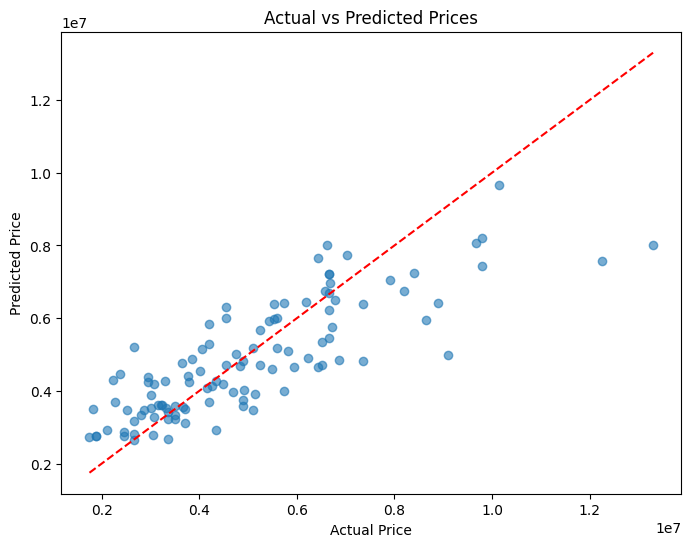

In [344]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()